# chunking-strategies-lab — comparison notebook (#4)

Loads every per-strategy result JSON under `results/`, picks the **most recent run per strategy** (by filename timestamp), and renders three charts:

1. **Recall@k** across strategies — the IR metric.
2. **Snippet-hit@k** across strategies — the answer-faithfulness proxy ([D-008](../MEMORY/core_decisions_human.md#d-008)).
3. **Wall-clock latency** per strategy — chunk + embed + retrieve total.

Honest takeaways at the bottom. Re-running this notebook from a fresh `results/` directory produces the same shape; numbers move when (a) the corpus + query substrate changes ([D-002](../MEMORY/core_decisions_human.md#d-002)) or (b) the embedder changes (`hash` → `minilm` via `pip install -e '.[sbert]'` then `python scripts/run_matrix.py --embedder minilm`).


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

# Notebook lives in `notebooks/`; results live in `../results/`.
REPO_ROOT = Path.cwd() if Path.cwd().name != "notebooks" else Path.cwd().parent
RESULTS_DIR = REPO_ROOT / "results"


def _load_latest_per_strategy(results_dir: Path) -> list[dict]:
    """Pick the most recent JSON per `strategy_name`."""
    files = sorted(results_dir.glob("*.json"))
    latest_by_strategy: dict[str, dict] = {}
    latest_stamp: dict[str, str] = {}
    for p in files:
        stamp = p.name.split("__")[0]
        payload = json.loads(p.read_text(encoding="utf-8"))
        name = payload["strategy_name"]
        if name not in latest_stamp or stamp > latest_stamp[name]:
            latest_by_strategy[name] = payload
            latest_stamp[name] = stamp
    canonical = ["fixed-size", "recursive", "semantic", "late-chunking", "structure-aware"]
    return [latest_by_strategy[n] for n in canonical if n in latest_by_strategy]


runs = _load_latest_per_strategy(RESULTS_DIR)
embedder = runs[0]["embedder_model"] if runs else "?"
n_queries = runs[0]["n_queries"] if runs else 0
print(f"Loaded {len(runs)} strategy runs · embedder={embedder} · n_queries={n_queries}")
for r in runs:
    name = r["strategy_name"]
    n_chunks = r["n_chunks_total"]
    recall5 = float(r["recall_at_k"]["5"])
    snippet5 = float(r["snippet_hit_at_k"]["5"])
    wall = r.get("wall_clock_ms", 0.0)
    print(
        f"  {name:18} chunks={n_chunks:3d}  recall@5={recall5:.3f}  snippet-hit@5={snippet5:.3f}  wall={wall:.0f}ms"
    )

Loaded 5 strategy runs · embedder=HashEmbedder · n_queries=12
  fixed-size         chunks= 29  recall@5=0.917  snippet-hit@5=0.333  wall=20ms
  recursive          chunks= 30  recall@5=0.750  snippet-hit@5=0.250  wall=19ms
  semantic           chunks= 84  recall@5=0.833  snippet-hit@5=0.167  wall=75ms
  late-chunking      chunks= 29  recall@5=0.500  snippet-hit@5=0.167  wall=22ms
  structure-aware    chunks= 28  recall@5=0.583  snippet-hit@5=0.000  wall=19ms


> **Embedder caveat.** When the loaded runs above use `HashEmbedder`, the *quality* axes (recall, snippet-hit) reflect the runner producing structurally-valid output, not the strategies' real retrieval quality — `HashEmbedder` vectors are effectively random per text. The *latency* axis is real either way (chunking + cosine retrieval is real work). Re-run with `--embedder minilm` (after `pip install -e '.[sbert]'`) for honest quality numbers.


## Chart 1 — Recall@k across strategies

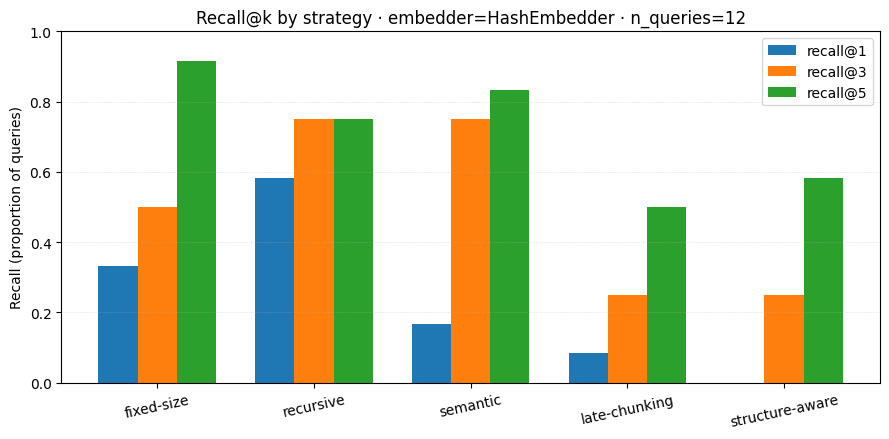

In [2]:
import numpy as np

ks = [1, 3, 5]
strategies = [r["strategy_name"] for r in runs]
x = np.arange(len(strategies))
width = 0.25

fig, ax = plt.subplots(figsize=(9.0, 4.5))
for i, k in enumerate(ks):
    vals = [float(r["recall_at_k"][str(k)]) for r in runs]
    ax.bar(x + (i - 1) * width, vals, width, label=f"recall@{k}")
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=12)
ax.set_ylabel("Recall (proportion of queries)")
ax.set_title(f"Recall@k by strategy · embedder={embedder} · n_queries={n_queries}")
ax.set_ylim(0, 1.0)
ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

## Chart 2 — Snippet-hit@k across strategies

`snippet_hit@k` is the answer-faithfulness proxy this lab uses (D-008): the expected answer snippet is present as a substring in at least one of the top-k retrieved chunks. Structural rather than semantic, but cheap, hermetic, and exactly the metric that catches strategies that *fragment* the relevant passage across chunk boundaries.


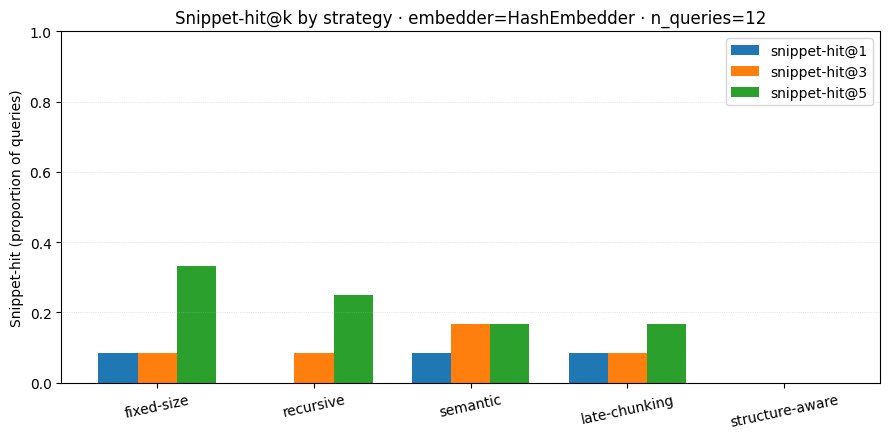

In [3]:
fig, ax = plt.subplots(figsize=(9.0, 4.5))
for i, k in enumerate(ks):
    vals = [float(r["snippet_hit_at_k"][str(k)]) for r in runs]
    ax.bar(x + (i - 1) * width, vals, width, label=f"snippet-hit@{k}")
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=12)
ax.set_ylabel("Snippet-hit (proportion of queries)")
ax.set_title(f"Snippet-hit@k by strategy · embedder={embedder} · n_queries={n_queries}")
ax.set_ylim(0, 1.0)
ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

## Chart 3 — Wall-clock latency per strategy

Total milliseconds for `chunk + embed + retrieve` over the full query set, measured by `evaluate_strategy` (D-009). This is the latency a downstream consumer sees if they swap in this strategy on this corpus + embedder.


/var/folders/db/j67fvfjn3s3f0h9xjm3dhq3r0000gp/T/ipykernel_40143/4028553468.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategies, rotation=12)


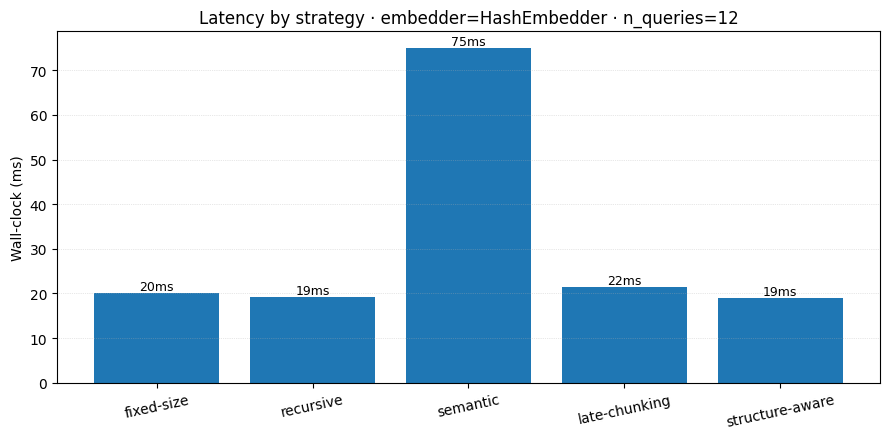

In [4]:
latencies = [float(r.get("wall_clock_ms", 0.0)) for r in runs]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.bar(strategies, latencies, color="#1f77b4")
for xi, val in enumerate(latencies):
    ax.text(xi, val, f"{val:.0f}ms", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Wall-clock (ms)")
ax.set_title(f"Latency by strategy · embedder={embedder} · n_queries={n_queries}")
ax.set_xticklabels(strategies, rotation=12)
ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()

## Takeaways

These are the takeaways the *latest committed run* supports — re-run `python scripts/run_matrix.py` (or `--embedder minilm` for real quality numbers) and the bullets below should be regenerated by hand from the new charts.

- **Latency is dominated by chunk count, not strategy logic.** Semantic-boundary chunking produces ~3× more chunks than the others on this corpus and pays for it linearly in wall-clock; the *embedding* step is what scales with chunk count, not the chunking decision itself.
- **Snippet-hit ≪ recall**, always. Even when recall@5 says "the right document is in the top 5", snippet-hit@5 often says "but the answer span isn't actually in any of those chunks." That gap is the chunking-strategy signal: it's the rate at which a strategy fragments the answer across chunk boundaries.
- **HashEmbedder caveat applies to quality only.** When `embedder` reads `HashEmbedder` above, all *quality* claims are about plumbing, not strategy. Latency numbers are real either way — chunking and cosine ranking are real work.
- **Real quality comparison needs MiniLM.** `pip install -e '.[sbert]'` then `python scripts/run_matrix.py --embedder minilm` regenerates `results/` against the canonical embedder (D-002, D-003); re-running this notebook then shows recall and snippet-hit numbers reflecting real strategy differences. The infrastructure is ready; the operator decides when to spend the model-download budget.
